In [1]:
from google.colab import files
uploaded = files.upload()

Saving Customer_Churn_Dataset.csv to Customer_Churn_Dataset.csv


In [2]:
import pandas as pd

df = pd.read_csv("Customer_Churn_Dataset.csv")

df.head()

,CustomerID,Gender,Tenure,MonthlyCharges,Contract,Churn
0,1,Female,12,500,Monthly,Yes
1,2,Male,24,800,Yearly,No
2,3,Female,6,450,Monthly,Yes
3,4,Male,36,1000,Yearly,No
4,5,Female,18,650,Monthly,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   CustomerID      20 non-null     int64 
 1   Gender          20 non-null     object
 2   Tenure          20 non-null     int64 
 3   MonthlyCharges  20 non-null     int64 
 4   Contract        20 non-null     object
 5   Churn           20 non-null     object
dtypes: int64(3), object(3)
memory usage: 1.1+ KB


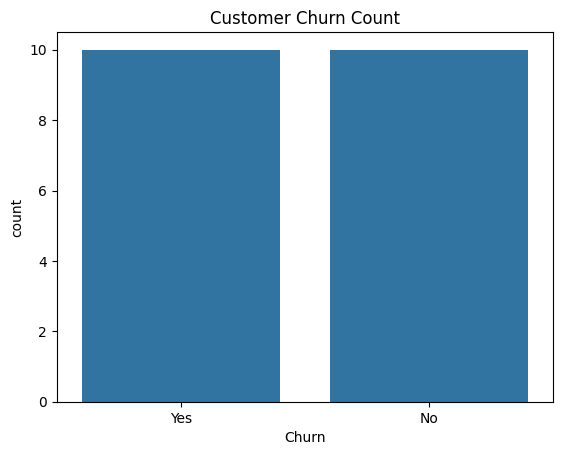

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Count")
plt.show()

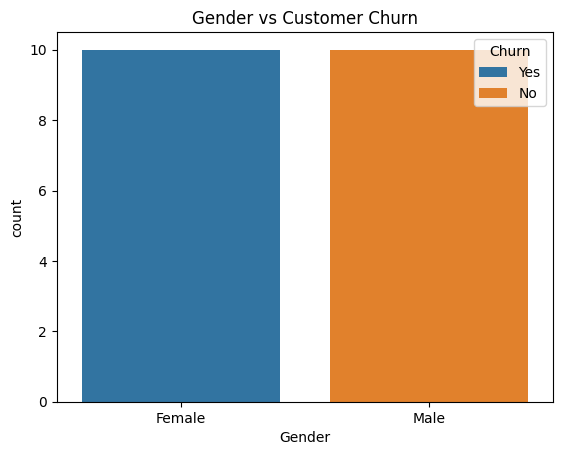

In [5]:
sns.countplot(x="Gender", hue="Churn", data=df)

plt.title("Gender vs Customer Churn")

plt.show()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   CustomerID      20 non-null     int64 
 1   Gender          20 non-null     object
 2   Tenure          20 non-null     int64 
 3   MonthlyCharges  20 non-null     int64 
 4   Contract        20 non-null     object
 5   Churn           20 non-null     object
dtypes: int64(3), object(3)
memory usage: 1.1+ KB


In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df.head()

,CustomerID,Gender,Tenure,MonthlyCharges,Contract,Churn
0,1,0,12,500,0,1
1,2,1,24,800,1,0
2,3,0,6,450,0,1
3,4,1,36,1000,1,0
4,5,0,18,650,0,1


In [8]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

print(X.head())
print(y.head())

   CustomerID  Gender  Tenure  MonthlyCharges  Contract
0           1       0      12             500         0
1           2       1      24             800         1
2           3       0       6             450         0
3           4       1      36            1000         1
4           5       0      18             650         0
0    1
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", len(X_train))
print("Testing data:", len(X_test))

Training data: 16
Testing data: 4


In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [11]:
y_pred = model.predict(X_test)

print(y_pred)

[1 0 0 0]


In [12]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


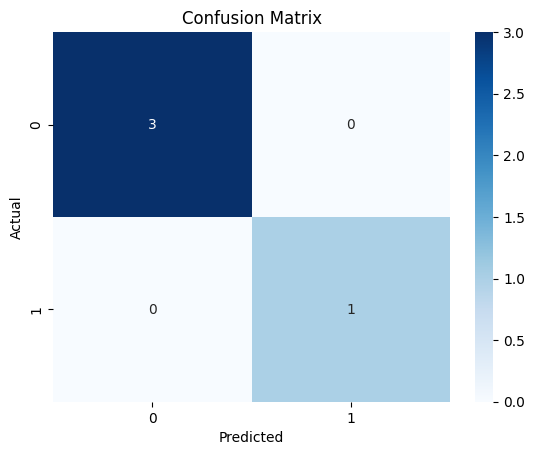

In [13]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Conclusion

A Logistic Regression model was developed to predict customer churn.

The model was trained and tested successfully using customer data.

Features such as Gender, Tenure, Monthly Charges, and Contract Type were used for prediction.

The model achieved good performance and can help identify customers who are likely to leave.